<a href="https://colab.research.google.com/github/abhishekanand04/ML-Adv-Supervised-Alogorithms/blob/mladv/Hiearchial_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  import pandas as pd
  import numpy as np
  from matplotlib import pyplot as plt
  plt.rcParams["figure.figsize"] = (18,10)
  import seaborn as sns

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2025-06-06 15:42:44--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 172.217.7.46, 2607:f8b0:4025:811::200e
Connecting to drive.google.com (drive.google.com)|172.217.7.46|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2025-06-06 15:42:44--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.0.65, 2607:f8b0:4025:803::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.0.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.-KB/s    in 0.03s   

2

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('./E-commerce.csv')
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [ ]:
df.set_index('ID',inplace=True)

In [ ]:
df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
ID,,,,,,
1476,130,65,213.905831,31.600751,233,235
1535,543,46,639.223004,5.689175,228,170
1807,520,102,1157.402763,844.321606,247,409
1727,702,83,1195.903634,850.041757,148,200
1324,221,84,180.754616,64.283300,243,259


In [ ]:
df.reset_index(drop=True,inplace=True)

In [ ]:
df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,130,65,213.905831,31.600751,233,235
1,543,46,639.223004,5.689175,228,170
2,520,102,1157.402763,844.321606,247,409
3,702,83,1195.903634,850.041757,148,200
4,221,84,180.754616,64.283300,243,259


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df)
X=scaler.transform(df)

In [ ]:
X

array([[0.06688963, 0.22088353, 0.03257084, 0.01301296, 0.45330739,
        0.4017094 ],
       [0.41220736, 0.14457831, 0.0973327 , 0.00234276, 0.44357977,
        0.29059829],
       [0.39297659, 0.36947791, 0.17623449, 0.34768545, 0.48054475,
        0.6991453 ],
       ...,
       [0.27173913, 0.40562249, 0.        , 0.        , 0.16342412,
        0.77606838],
       [0.18478261, 0.08835341, 0.48580837, 0.03217462, 0.21595331,
        0.36752137],
       [0.63879599, 0.45381526, 0.21235018, 0.43873046, 0.48249027,
        0.25470085]])

In [ ]:
scaled_df = pd.DataFrame(X, columns=df.columns, index=df.index)

In [ ]:
scaled_df

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,0.066890,0.220884,0.032571,0.013013,0.453307,0.401709
1,0.412207,0.144578,0.097333,0.002343,0.443580,0.290598
2,0.392977,0.369478,0.176234,0.347685,0.480545,0.699145
3,0.545151,0.293173,0.182097,0.350041,0.287938,0.341880
4,0.142977,0.297189,0.027523,0.026471,0.472763,0.442735
...,...,...,...,...,...,...
2495,0.630435,0.441767,0.076536,0.153769,0.706226,0.182906
2496,0.361204,0.200803,0.080704,0.050502,0.217899,0.605128
2497,0.271739,0.405622,0.000000,0.000000,0.163424,0.776068
2498,0.184783,0.088353,0.485808,0.032175,0.215953,0.367521


In [ ]:
import scipy.cluster.hierarchy as sch

Z = sch.linkage(scaled_df, method='ward')

Text(0, 0.5, 'distance')

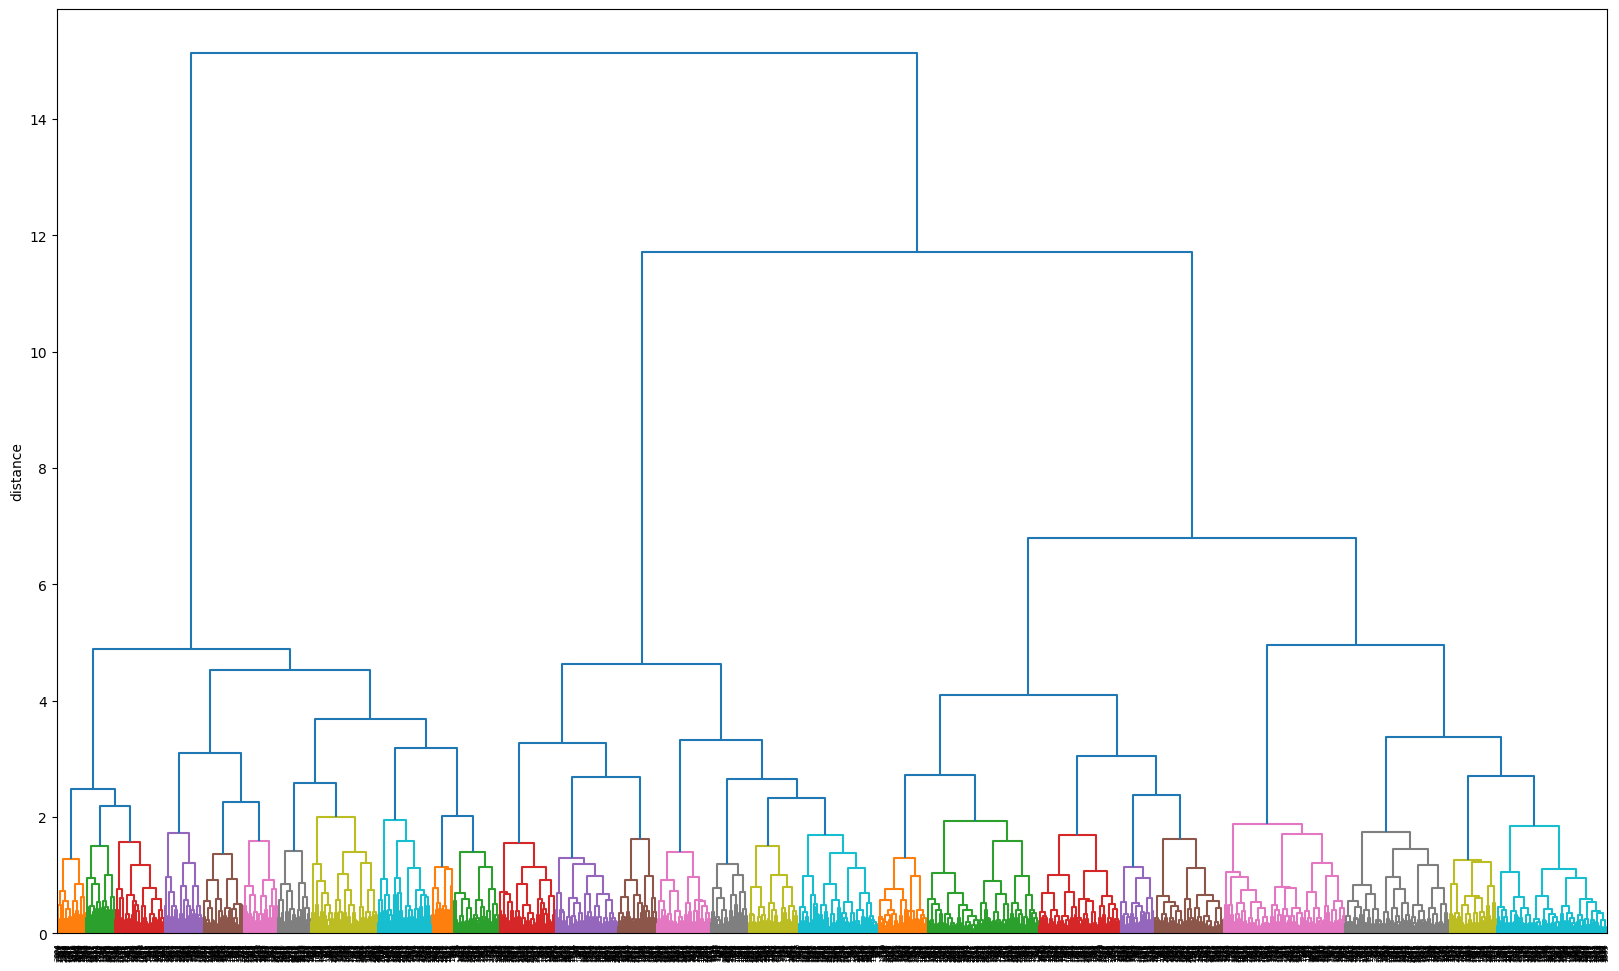

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
sch.dendrogram(Z, labels=scaled_df.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
ax.set_ylabel('distance')

In [ ]:
# import hierarchical clustering libraries
from sklearn.cluster import AgglomerativeClustering


# create clusters
hc_2020 = AgglomerativeClustering(n_clusters=5, metric = 'euclidean', linkage = 'ward')
y_pred = hc_2020.fit_predict(scaled_df)

In [ ]:
viz_df = scaled_df
viz_df['Y_Predicted'] = y_pred

In [ ]:
viz_df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information,Y_Predicted
0,0.066890,0.220884,0.032571,0.013013,0.453307,0.401709,1
1,0.412207,0.144578,0.097333,0.002343,0.443580,0.290598,1
2,0.392977,0.369478,0.176234,0.347685,0.480545,0.699145,0
3,0.545151,0.293173,0.182097,0.350041,0.287938,0.341880,0
4,0.142977,0.297189,0.027523,0.026471,0.472763,0.442735,1


In [ ]:
from sklearn.metrics import silhouette_score

# Hierarchical clustering
def hierarchical_clustering_silhouette(scaled_df, n_clusters):
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(scaled_df)
    silhouette_avg = silhouette_score(scaled_df, labels)
    return silhouette_avg

# Evaluate silhouette score for different numbers of clusters
for n_clusters in range(2, 9):
    silhouette_avg = hierarchical_clustering_silhouette(scaled_df, n_clusters)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")

For n_clusters = 2, the average silhouette_score is : 0.521381832540533
For n_clusters = 3, the average silhouette_score is : 0.5487320019932623
For n_clusters = 4, the average silhouette_score is : 0.6004998960773777
For n_clusters = 5, the average silhouette_score is : 0.6407224249764286
For n_clusters = 6, the average silhouette_score is : 0.5111577010854139
For n_clusters = 7, the average silhouette_score is : 0.3972636647176375
For n_clusters = 8, the average silhouette_score is : 0.3954345110491139


### PCA

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Attaching labels for data points
labels = scaled_df['Y_Predicted']

# Create DataFrame
pca_df = pd.DataFrame(data=np.vstack((pca_data.T, labels)).T, columns=("1st_principal", "2nd_principal", "label"))




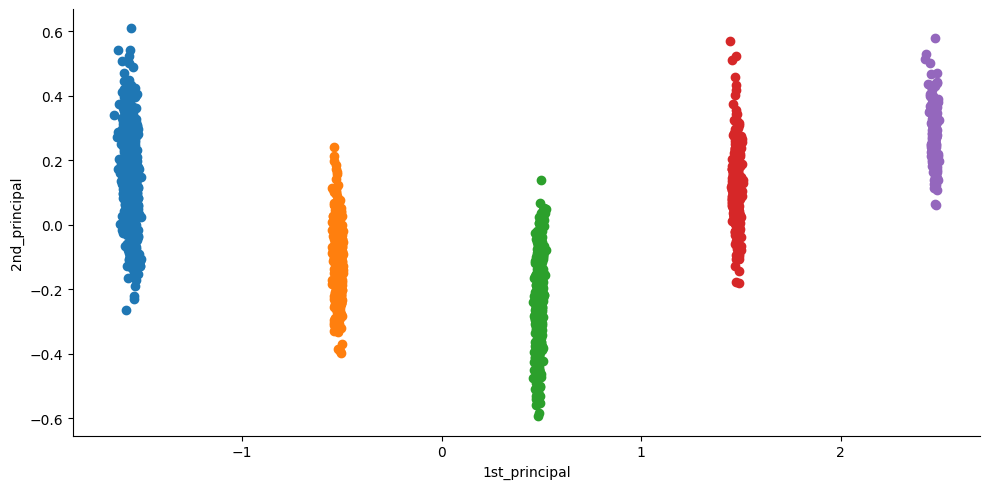

In [ ]:
# Visualization
g = sns.FacetGrid(pca_df, hue="label",height=5 ,aspect= 2)
g.map(plt.scatter, '1st_principal', '2nd_principal')
plt.show()

### TSNE

In [ ]:
from sklearn.manifold import TSNE

# t-SNE dimensionality reduction
model = TSNE(n_components=2, random_state=0, perplexity=50)
tsne_data = model.fit_transform(scaled_df)

# Create DataFrame for plotting
tsne_df = pd.DataFrame(data=np.vstack((tsne_data.T, scaled_df['Y_Predicted'])).T, columns=("Dim_1", "Dim_2", "label"))



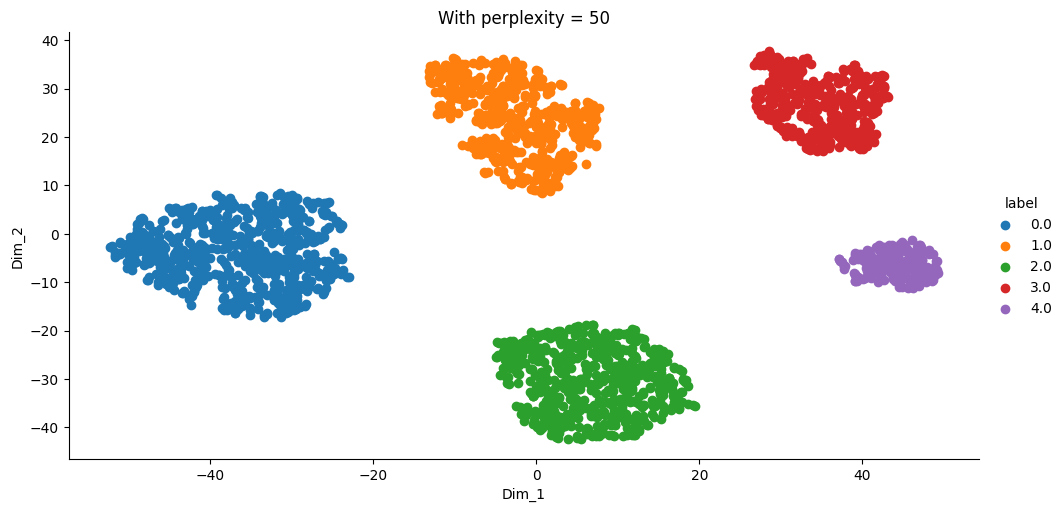

In [ ]:
# Plot using Seaborn
sns.FacetGrid(tsne_df, hue="label", height=5 ,aspect= 2).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 50')
plt.show()
